In [1]:
import numpy as np
import scipy as sp
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff
import matplotlib.pyplot as plt

In [2]:
dim = 1
aw = 0.02
bw = 1
cw = 0.04
dw = 0
gw = 3.076278e-2
rw = 0.7071067
vol = 1000
w0 = 12.35
cUp = 0.0382

def infPotFunc(phi):
    x = np.exp(phi / np.sqrt(3))
    return float(w0**2 / vol**3 * (cUp / vol**(1/3) + aw / (x - bw) - cw / x + x**2 / vol * (dw - gw / (rw * x**3 / vol + 1))))

def infPotDerivFunc(phi):
    x = np.exp(phi / np.sqrt(3))
    return float(w0**2 / vol**3 * (-aw / (x - bw)**2 + cw / x**2 + 2 * x * (dw / vol - gw / (rw * x**3 + vol)) + 3 * gw * rw * x**4 / (rw * x**3 + vol)**2) * x / np.sqrt(3))

def infPotDeriv2Func(phi):
    x = np.exp(phi / np.sqrt(3))
    return infPotDerivFunc(phi) / np.sqrt(3) + \
        float(w0**2 / vol**3 * (2 * aw / (x - bw)**3 - 2 * cw / x**3 + 2 * (dw / vol - gw / (rw * x**3 + vol)) + 18 * gw * rw * x**3 / (rw * x**3 + vol)**2 - 18 * gw * rw * rw * x**6 / (rw * x**3 + vol)**3) * x**2 / 3)

infPotentialDerivFuncs = [infPotDerivFunc]
infPotentialDeriv2Funcs = [infPotDeriv2Func]

In [3]:
def slowrollEps(phi):
    return 0.5 * (infPotDerivFunc(phi) / infPotFunc(phi))**2

def slowrollEta(phi):
    return infPotDeriv2Func(phi) / infPotFunc(phi)

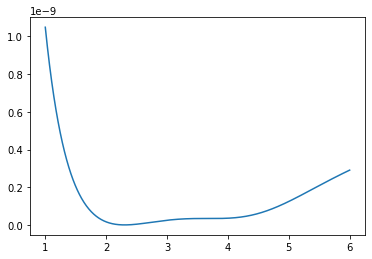

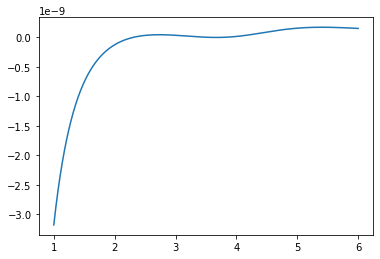

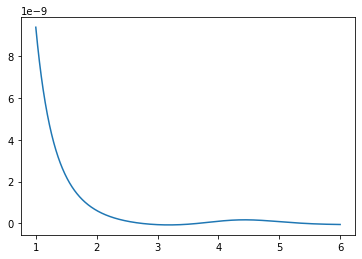

In [4]:
phis = np.linspace(1, 6, 1000)
vs = [infPotFunc(phi) for phi in phis]
vDers = [infPotDerivFunc(phi) for phi in phis]
vDer2s = [infPotDeriv2Func(phi) for phi in phis]

ax = plt.gca()
plt.plot(phis, vs)
plt.show()

ax = plt.gca()
plt.plot(phis, vDers)
plt.show()

ax = plt.gca()
plt.plot(phis, vDer2s)
plt.show()

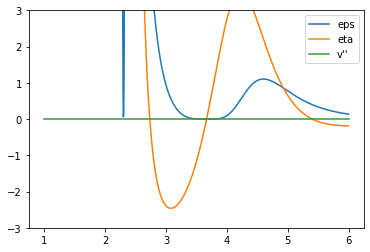

In [5]:
epss = [slowrollEps(phi) for phi in phis]
etas = [slowrollEta(phi) for phi in phis]

ax = plt.gca()
plt.plot(phis, epss, label="eps")
plt.plot(phis, etas, label="eta")
plt.plot(phis, vDer2s, label="v''")
ax.set_ylim(-3, 3)
plt.legend()
plt.show()

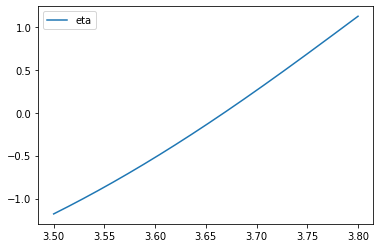

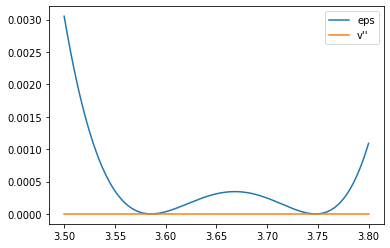

In [6]:
phisAroundInflec = np.linspace(3.5, 3.8, 1000)

epssAroundInfle = [slowrollEps(phi) for phi in phisAroundInflec]
etasAroundInfle = [slowrollEta(phi) for phi in phisAroundInflec]
vDer2sAroundInfle = [infPotDeriv2Func(phi) for phi in phisAroundInflec]

ax = plt.gca()
plt.plot(phisAroundInflec, etasAroundInfle, label="eta")
plt.legend()
plt.show()

ax = plt.gca()
plt.plot(phisAroundInflec, epssAroundInfle, label="eps")
plt.plot(phisAroundInflec, vDer2sAroundInfle, label="v''")
plt.legend()
plt.show()

In [7]:
# eta=±1の点として上下限を決める
upperBound = sp.optimize.bisect(lambda phi: slowrollEta(phi) - 1, 3.5, 3.8)
lowerBound = sp.optimize.bisect(lambda phi: slowrollEta(phi) + 1, 3.5, 3.8)
print(lowerBound, upperBound)

3.529369783189395 3.785924333345246


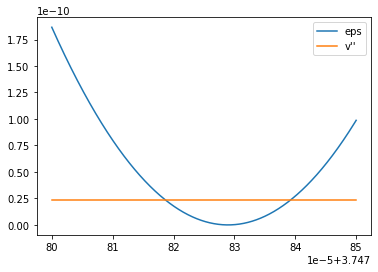

In [8]:
phisAroundInflec = np.linspace(3.7478, 3.74785, 1000)

epssAroundInfle = [slowrollEps(phi) for phi in phisAroundInflec]
vDer2sAroundInfle = [infPotDeriv2Func(phi) for phi in phisAroundInflec]

ax = plt.gca()
plt.plot(phisAroundInflec, epssAroundInfle, label="eps")
plt.plot(phisAroundInflec, vDer2sAroundInfle, label="v''")
plt.legend()
plt.show()

In [18]:
nGrid = 10000 
grids = np.linspace(lowerBound, upperBound, nGrid)

In [19]:
fpFinDiff_DirNeu = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Neumann0"],
    ["Dirichlet"]
)

eigVals_DirNeu, eigVecs_DirNeu = np.linalg.eig(fpFinDiff_DirNeu)
eigVecsSort_DirNeu = eigVecs_DirNeu.T[np.argsort(eigVals_DirNeu)]
eigValsSort_DirNeu = np.sort(eigVals_DirNeu)

In [20]:
fpFinDiff_DirDir = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    infPotentialDeriv2Funcs,
    [nGrid],
    [upperBound],
    [lowerBound],
    ["Dirichlet"],
    ["Dirichlet"]
)

eigVals_DirDir, eigVecs_DirDir = np.linalg.eig(fpFinDiff_DirDir)
eigVecsSort_DirDir = eigVecs_DirDir.T[np.argsort(eigVals_DirDir)]
eigValsSort_DirDir = np.sort(eigVals_DirDir)

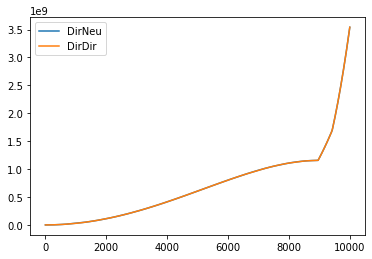

In [21]:
nMode = np.arange(nGrid)

ax = plt.gca()
plt.plot(nMode, eigValsSort_DirNeu, label = "DirNeu")
plt.plot(nMode, eigValsSort_DirDir, label = "DirDir")
plt.legend()
plt.show()

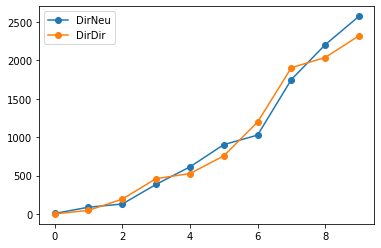

In [22]:
ax = plt.gca()
plt.plot(np.arange(10), eigValsSort_DirNeu[:10], marker='o', label = "DirNeu")
plt.plot(np.arange(10), eigValsSort_DirDir[:10], marker='o', label = "DirDir")
plt.legend()
plt.show()

In [23]:
print(eigValsSort_DirNeu[:10])
print(eigValsSort_DirDir[:10])

[   6.25277869   87.48278177  129.21105288  385.16590447  612.69462556
  902.26045866 1026.69832561 1750.41747842 2203.50831049 2574.29120643]
[1.99136806e-01 4.66713126e+01 1.92977109e+02 4.60297315e+02
 5.25404871e+02 7.56117432e+02 1.19578158e+03 1.90471651e+03
 2.03689775e+03 2.32056888e+03]


「下端：ディリクレ、上端：ノイマン」と「下端：ディリクレ、上端：ノイマン」で、固有値ほぼ一致

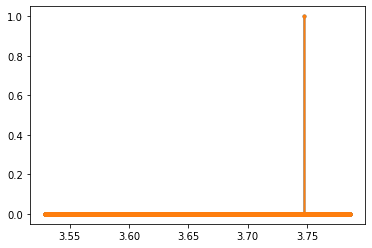

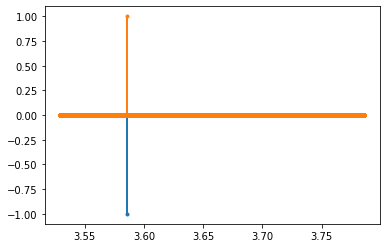

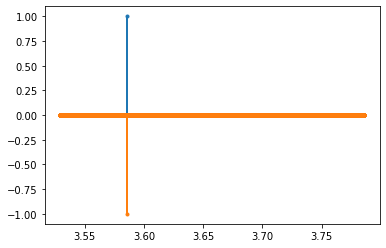

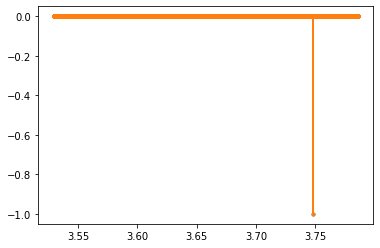

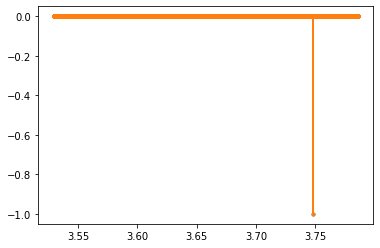

In [24]:
# 固有関数のプロット（-1倍の違いがある場合もあるが、それを除けば一致）
ax = plt.gca()

for iEig in range(5):
    plt.plot(grids, eigVecsSort_DirNeu[iEig],marker='.', label="DirNeu")
    plt.plot(grids, eigVecsSort_DirDir[iEig],marker='.', label="DirDir")
    plt.show()

2個inflection pointがあり、その周りだけ細かく分解するのも面倒...